# חלק 1 : רגרסיה

In [1]:
from google.colab import files
uploaded = files.upload()

Saving auto+mpg.zip to auto+mpg.zip


# זיהוי ערכים חסרים

In [3]:
import pandas as pd
import zipfile
# הגדרת שמות העמודות לפי התיעוד [cite: 2051, 2052]
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

# טעינת הנתונים מתוך ה-ZIP והחלפת '?' ב-NaN
with zipfile.ZipFile('auto+mpg.zip', 'r') as z:
    with z.open('auto-mpg.data') as f:
        df = pd.read_csv(f, sep='\s+', names=column_names, na_values='?')

# הצגת כמות הערכים החסרים בכל עמודה
print("Missing values per feature:")
print(df.isnull().sum())

Missing values per feature:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_361/2345570206.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(f, sep='\s+', names=column_names, na_values='?')


# התפלגות משתנה המטרה

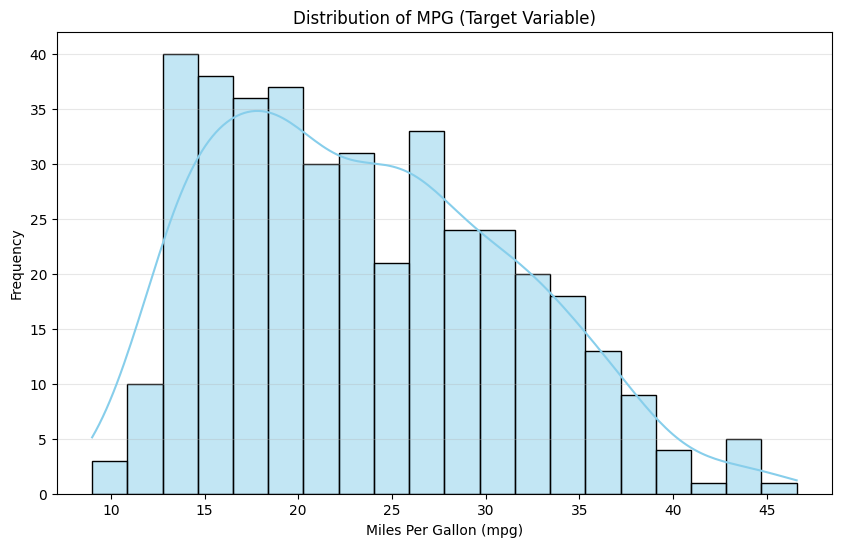

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['mpg'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of MPG (Target Variable)')
plt.xlabel('Miles Per Gallon (mpg)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# קשר בין המאפיינים למשתנה המטרה

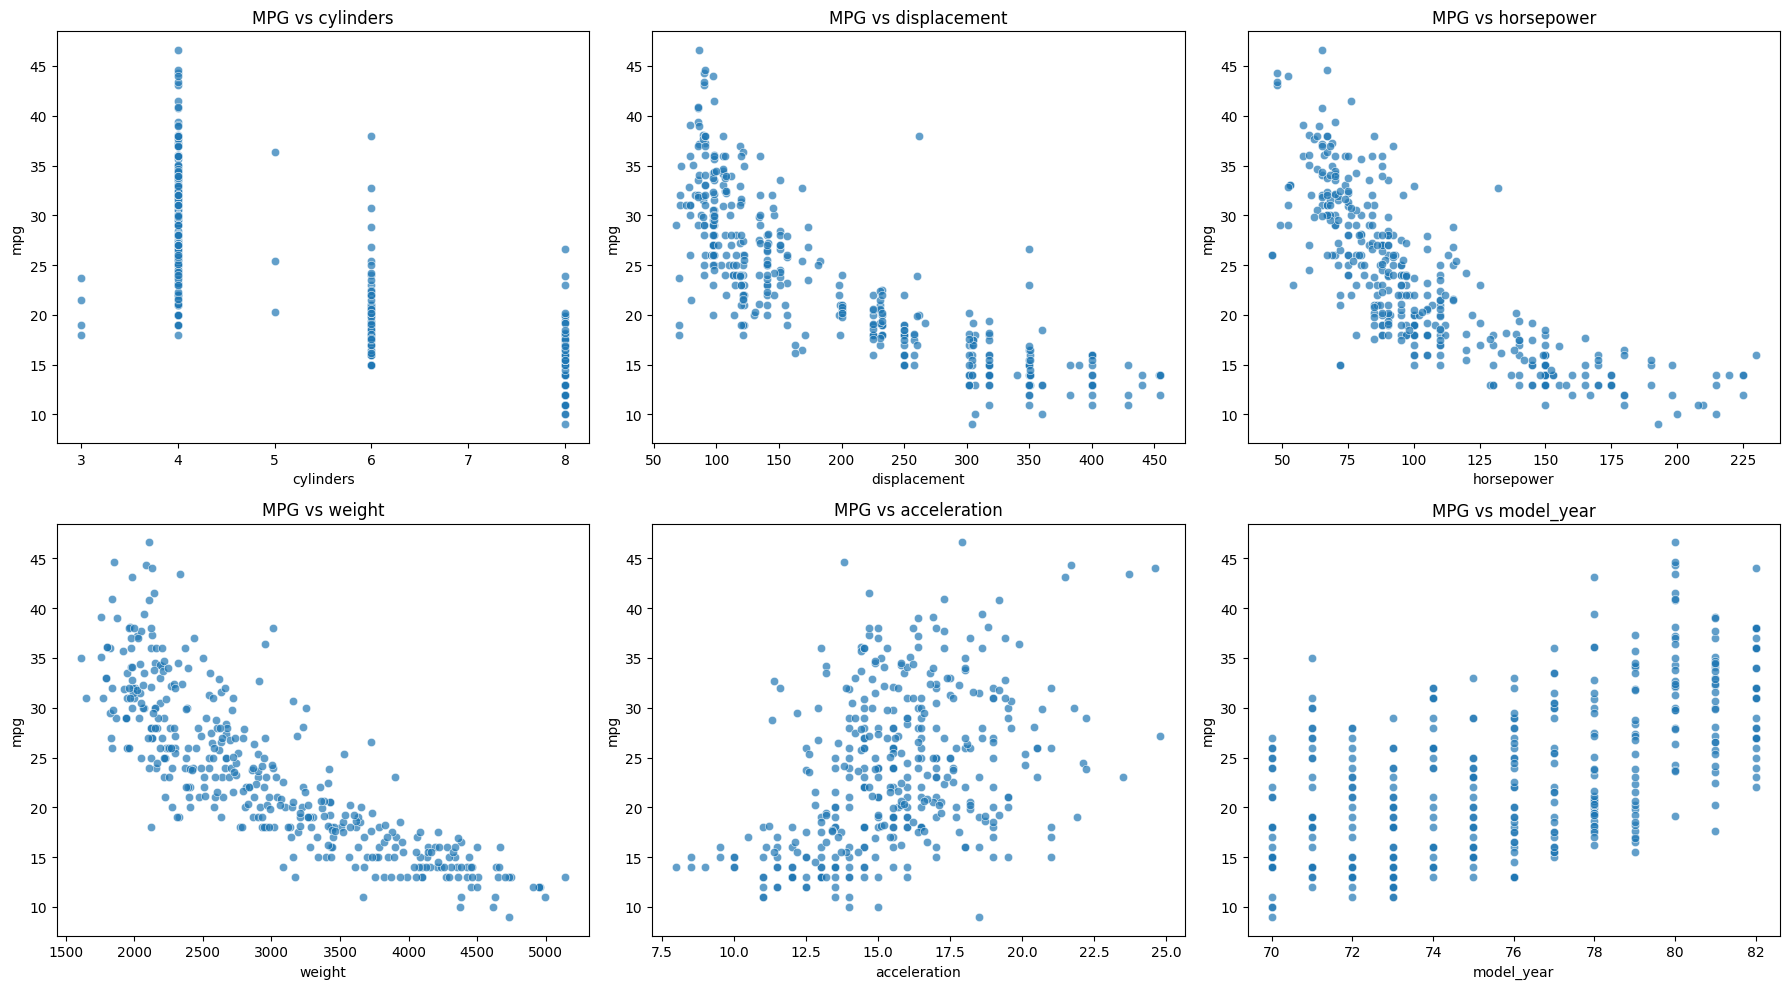

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# רשימת מאפיינים מספריים לניתוח (מתוך המאפיינים הזמינים בדאטה) [cite: 9, 316]
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    # יצירת גרף פיזור עבור כל מאפיין מול משתנה המטרה mpg [cite: 326]
    sns.scatterplot(data=df, x=feature, y='mpg', ax=axes[i], alpha=0.7)
    axes[i].set_title(f'MPG vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('mpg')

plt.tight_layout()
plt.show()

/tmp/ipykernel_361/3547501878.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=feature, y='mpg', ax=axes[i], palette="muted", inner="quartile")
/tmp/ipykernel_361/3547501878.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=feature, y='mpg', ax=axes[i], palette="muted", inner="quartile")


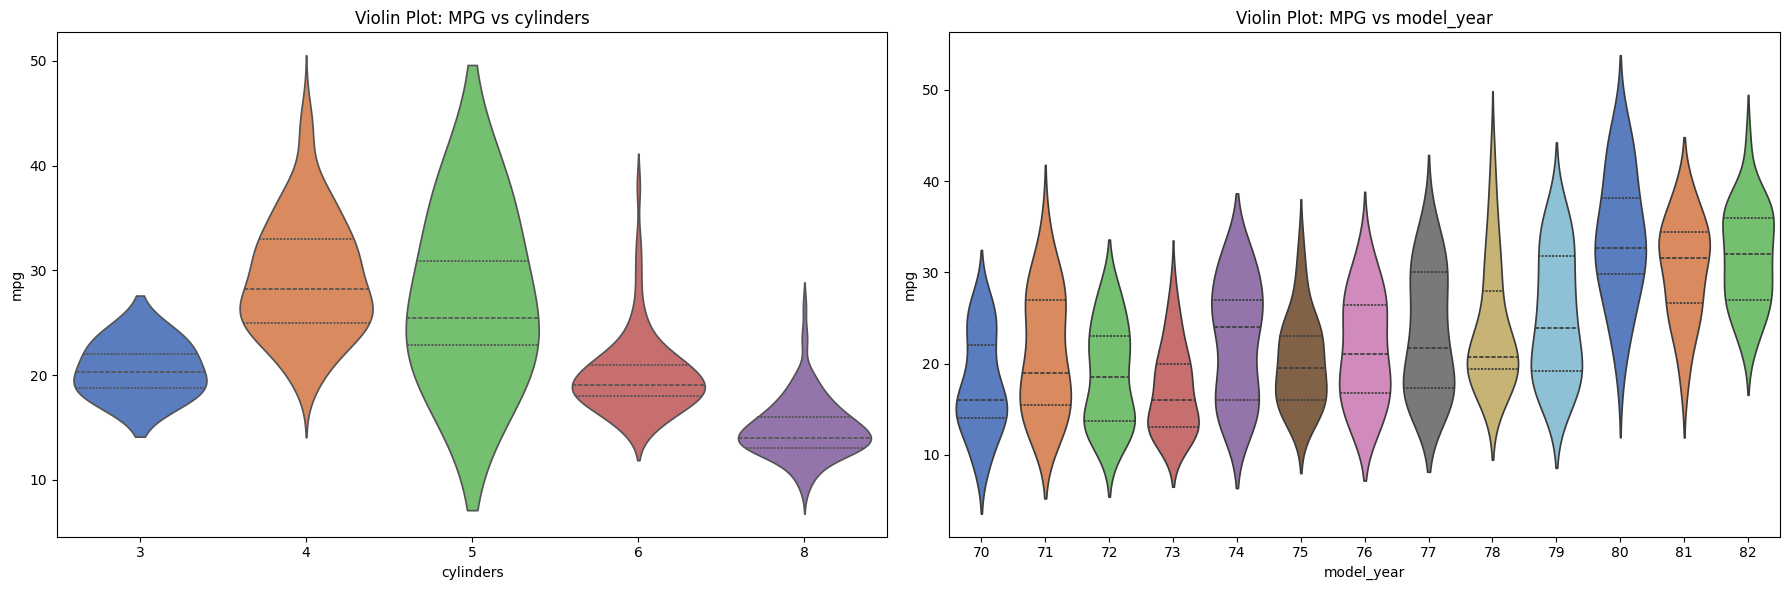

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרת המשתנים שאנחנו רוצים לבדוק
features = ['cylinders', 'model_year']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, feature in enumerate(features):
    # יצירת Violin plot - מראה את צפיפות הנתונים והתפלגותם
    sns.violinplot(data=df, x=feature, y='mpg', ax=axes[i], palette="muted", inner="quartile")
    axes[i].set_title(f'Violin Plot: MPG vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('mpg')

plt.tight_layout()
plt.show()

/tmp/ipykernel_361/211325076.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='mpg', ax=axes[i], palette="Set2")
/tmp/ipykernel_361/211325076.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='mpg', ax=axes[i], palette="Set2")


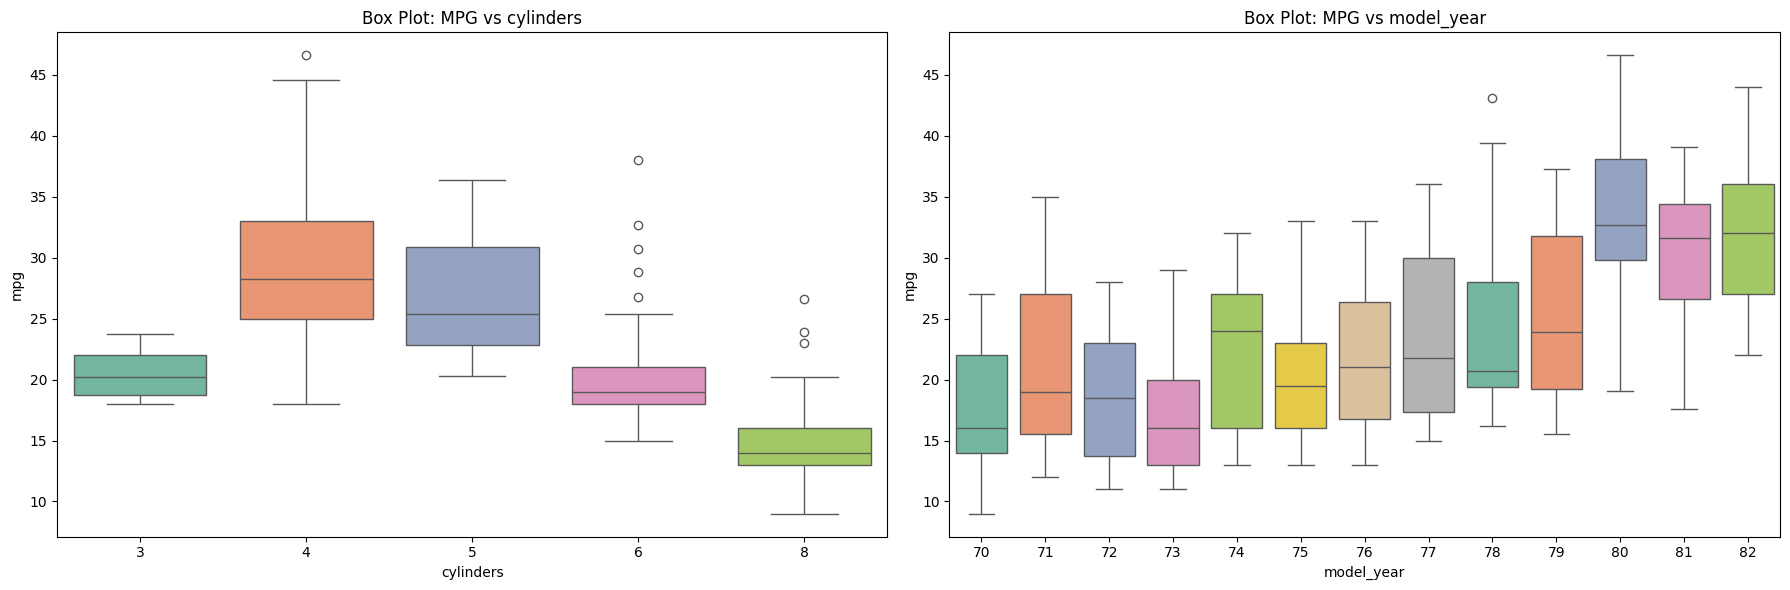

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרת המשתנים
features = ['cylinders', 'model_year']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, feature in enumerate(features):
    # יצירת Box plot - מצוין לזיהוי חציונים וערכים חריגים (Outliers)
    sns.boxplot(data=df, x=feature, y='mpg', ax=axes[i], palette="Set2")
    axes[i].set_title(f'Box Plot: MPG vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('mpg')

plt.tight_layout()
plt.show()

In [10]:
from scipy import stats

# 1. בדיקת קורלציה בין mpg לצילינדרים
corr_cyl, p_val_cyl = stats.pearsonr(df['cylinders'], df['mpg'])

# 2. בדיקת קורלציה בין mpg לשנת המודל
corr_year, p_val_year = stats.pearsonr(df['model_year'], df['mpg'])

print(f"--- בדיקת קשר: mpg מול cylinders ---")
print(f"מתאם פירסון: {corr_cyl:.3f}")
print(f"p-value: {p_val_cyl:.4e}")

print(f"\n--- בדיקת קשר: mpg מול model_year ---")
print(f"מתאם פירסון: {corr_year:.3f}")
print(f"p-value: {p_val_year:.4e}")

--- בדיקת קשר: mpg מול cylinders ---
מתאם פירסון: -0.775
p-value: 4.5040e-81

--- בדיקת קשר: mpg מול model_year ---
מתאם פירסון: 0.579
p-value: 4.8449e-37


# מתאמים בין המאפיינים

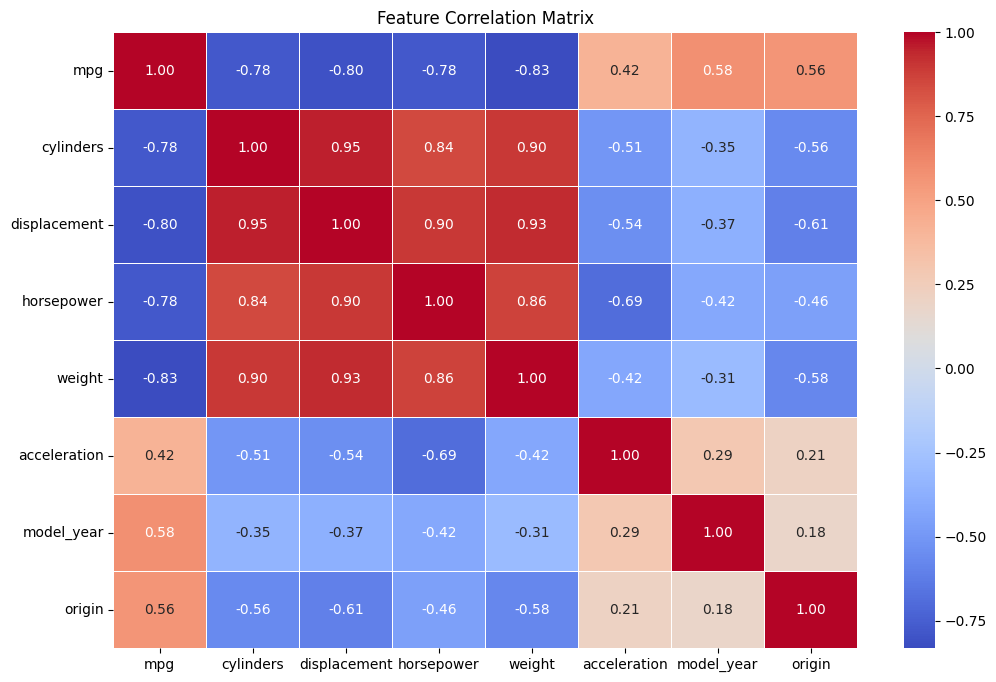

In [12]:
plt.figure(figsize=(12, 8))
# הסרת עמודת car_name שהיא מחרוזת
correlation_matrix = df.drop('car_name', axis=1).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# טיפול בערכים החסרים ובחירת מאפיינים

In [30]:
# הסרת שורות עם ערכים חסרים (NaN) בעמודת horsepower
# מומלץ להסיר אותן מכיוון שמדובר בכמות קטנה מאוד של דגימות
df_clean = df.dropna(subset=['horsepower'])

# בחירת המאפיינים (Features)
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

# סינון ערכים חריגים (Outliers) - יותר מ-2 סטיות תקן
for col in features:
    mean = df_clean[col].mean()
    std = df_clean[col].std()
    # שמירת רק את השורות שנמצאות בטווח של מינוס 2 עד פלוס 2 סטיות תקן
    df_clean = df_clean[(df_clean[col] >= mean - 2 * std) & (df_clean[col] <= mean + 2 * std)]

# חלוקה למאפיינים (X) ומשתנה מטרה (y) לאחר הסינון
X = df_clean[features]
y = df_clean['mpg']

print(f"Original instances: {len(df)}")
print(f"Instances after removing missing values and outliers: {len(df_clean)}")

Original instances: 392
Instances after removing missing values and outliers: 336


# פיצול הנתונים ל train , test and validation

In [14]:
from sklearn.model_selection import train_test_split

# פיצול ראשון: 85% אימון+ולידציה, 15% בדיקה (Test) [cite: 369]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# פיצול שני: חלוקת ה-85% ל-70% אימון ו-15% ולידציה [cite: 347]
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.176, random_state=42)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 274, Validation size: 59, Test size: 59


# נרמול

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# התאמה וטרנספורמציה על נתוני האימון
X_train_scaled = scaler.fit_transform(X_train)

# טרנספורמציה בלבד על נתוני הולידציה והבדיקה (למניעת זליגת מידע)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Standardization complete.")

Standardization complete.


# **אימון מודל רגרסיה לנארית**

מצאנו והעפנו 25 רכבים שהרסו את הרגרסיה (Cook's D > 0.0102)

Starting 50 trials of Optuna Feature Selection for Pure Linear Regression...
Optimization Finished!
Best Features Selected: ['weight', 'model_year', 'origin']

Final STRICT Linear Regression Metrics (Clean Data):
R^2:   0.8832
RMSE:  2.7637
MAE:   2.1629


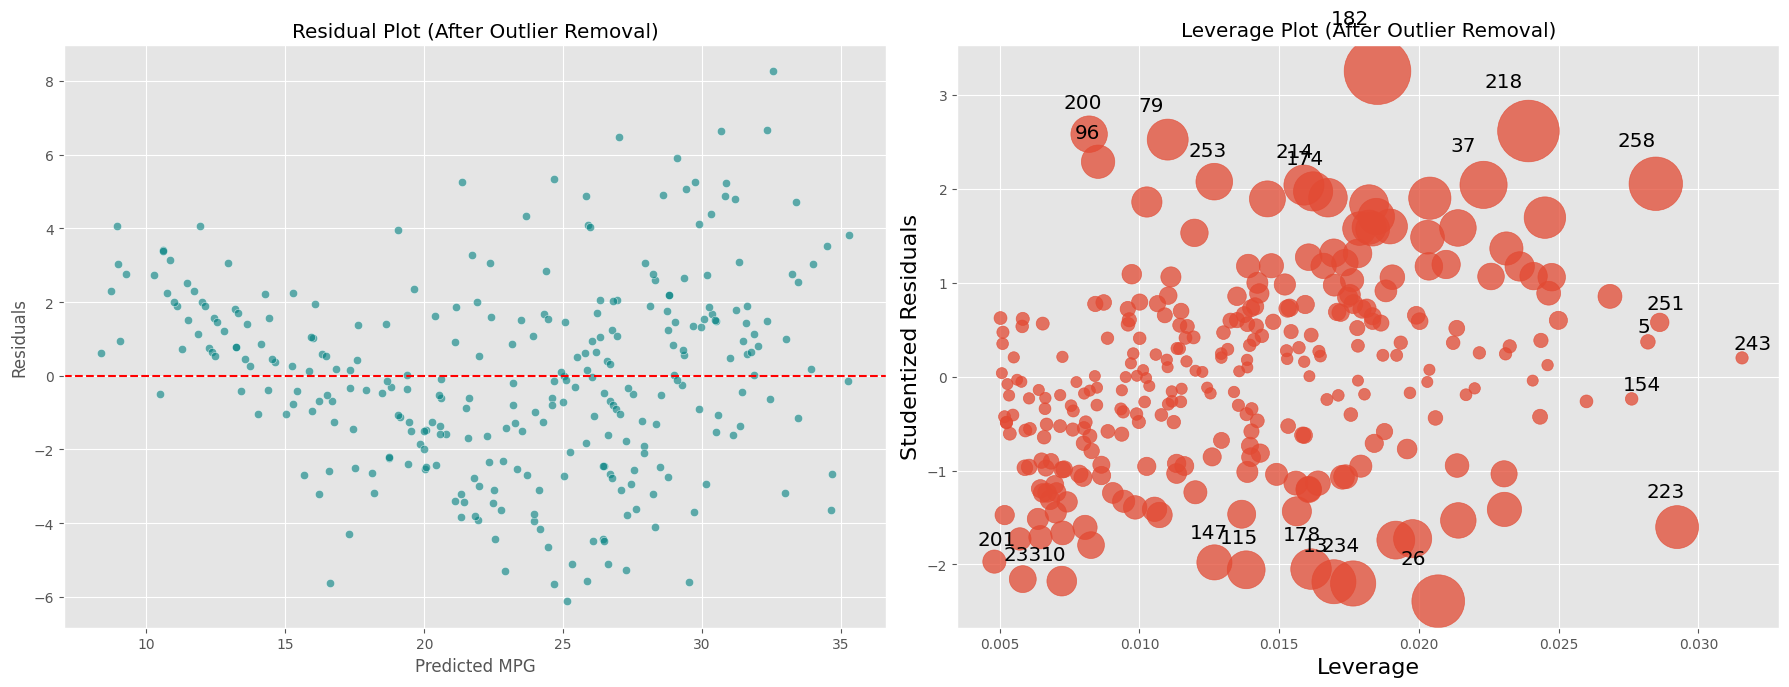

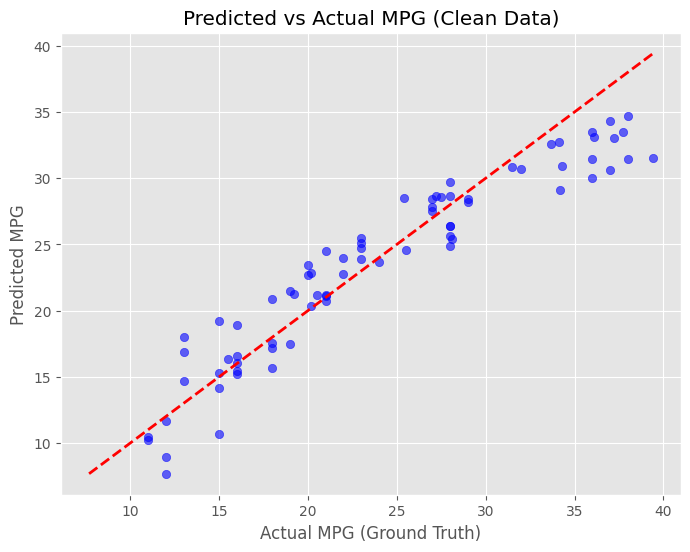

In [32]:
import pandas as pd
import numpy as np
import zipfile
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- שלב 1: טעינת הנתונים ---
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

try:
    with zipfile.ZipFile('auto+mpg.zip', 'r') as z:
        with z.open('auto-mpg.data') as f:
            df = pd.read_csv(f, sep=r'\s+', names=column_names, na_values='?')
except FileNotFoundError:
    print("קובץ ה-ZIP לא נמצא. וודאי שהוא הועלה למחברת.")

# ניקוי ראשוני
df = df.dropna()
df = df.drop('car_name', axis=1)

# --- שלב חדש: זיהוי והסרת Outliers הרסניים בעזרת מרחק קוק (Cook's Distance) ---
# נבנה מודל OLS זמני רק כדי לאתר מי הנקודות שמושכות את הרגרסיה
X_temp = df.drop('mpg', axis=1)
y_temp = df['mpg']

# הוספת קבוע עבור statsmodels
X_temp_sm = sm.add_constant(X_temp)
model_initial = sm.OLS(y_temp, X_temp_sm).fit()

# חישוב מרחק קוק לכל רכב
influence = model_initial.get_influence()
cooks_d, pvals = influence.cooks_distance

# הגדרת סף קריטי (כלל אצבע ידוע: 4 חלקי מספר התצפיות)
threshold = 4 / len(df)

# מציאת האינדקסים של הרכבים ההרסניים
outlier_indices = np.where(cooks_d > threshold)[0]
df_clean = df.drop(df.index[outlier_indices])

print("="*40)
print(f"מצאנו והעפנו {len(outlier_indices)} רכבים שהרסו את הרגרסיה (Cook's D > {threshold:.4f})")
print("="*40)

# עכשיו ממשיכים עם הנתונים הנקיים (df_clean)
X = df_clean.drop('mpg', axis=1)
y = df_clean['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- שלב 3: אופטימיזציה עם Optuna (בחירת מאפיינים לרגרסיה ליניארית טהורה) ---
def objective(trial):
    features_to_use = []
    for col in X.columns:
        if trial.suggest_categorical(f'use_{col}', [True, False]):
            features_to_use.append(col)

    if len(features_to_use) == 0:
        features_to_use = list(X.columns)

    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])

    X_train_sub = X_train[features_to_use]

    scaler = StandardScaler()
    X_train_scaled_sub = scaler.fit_transform(X_train_sub)

    model = LinearRegression(fit_intercept=fit_intercept)
    score = cross_val_score(model, X_train_scaled_sub, y_train, cv=5, scoring='neg_mean_squared_error')
    return -score.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\nStarting 50 trials of Optuna Feature Selection for Pure Linear Regression...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_features = []
for col in X.columns:
    if study.best_params.get(f'use_{col}', False):
        best_features.append(col)
if len(best_features) == 0:
    best_features = list(X.columns)

best_intercept = study.best_params['fit_intercept']

print(f"Optimization Finished!")
print(f"Best Features Selected: {best_features}")

# --- שלב 4: אימון המודל הסופי המנצח והצגת מדדים ---
X_train_final = X_train[best_features]
X_test_final = X_test[best_features]

scaler = StandardScaler()
X_train_scaled_final = scaler.fit_transform(X_train_final)
X_test_scaled_final = scaler.transform(X_test_final)

final_model = LinearRegression(fit_intercept=best_intercept)
final_model.fit(X_train_scaled_final, y_train)

y_pred = final_model.predict(X_test_scaled_final)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*40)
print("Final STRICT Linear Regression Metrics (Clean Data):")
print(f"R^2:   {r2:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")
print("="*40)

# --- שלב 5: גרפי אבחון (Residual & Leverage) על הנתונים הנקיים ---
if best_intercept:
    X_train_sm = sm.add_constant(X_train_scaled_final)
else:
    X_train_sm = X_train_scaled_final

sm_model = sm.OLS(y_train.values, X_train_sm).fit()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

y_train_pred = final_model.predict(X_train_scaled_final)
residuals = y_train - y_train_pred
sns.scatterplot(x=y_train_pred, y=residuals, ax=ax1, alpha=0.6, color='teal')
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Residual Plot (After Outlier Removal)')
ax1.set_xlabel('Predicted MPG')
ax1.set_ylabel('Residuals')

sm.graphics.influence_plot(sm_model, ax=ax2, criterion="cooks")
ax2.set_title('Leverage Plot (After Outlier Removal)')

plt.tight_layout()
plt.show()

# --- שלב 6: ויזואליזציה של הרגרסיה ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.title('Predicted vs Actual MPG (Clean Data)')
plt.xlabel('Actual MPG (Ground Truth)')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

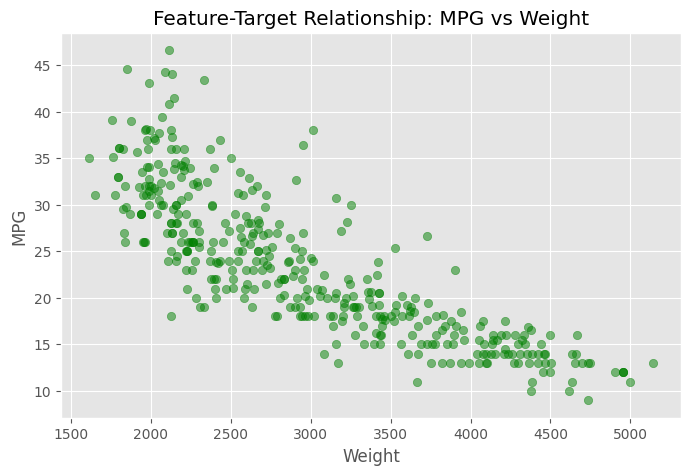

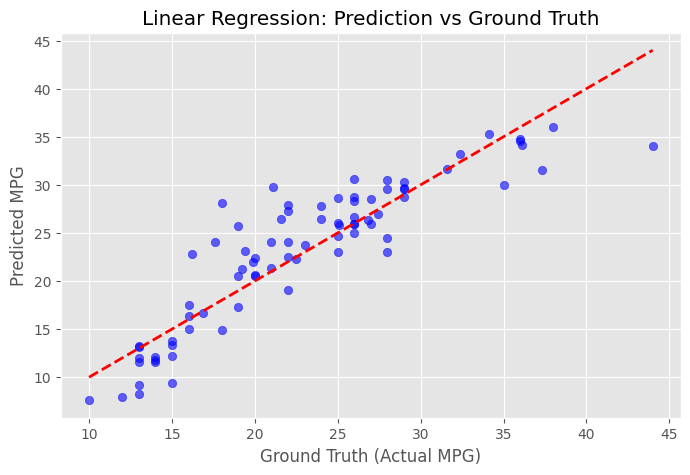

In [28]:
import matplotlib.pyplot as plt

# גרף 1: הקשר בין המשקל (Weight) לצריכת הדלק (MPG)
plt.figure(figsize=(8, 5))
# עודכן ל-df במקום df_clean
plt.scatter(df['weight'], df['mpg'], alpha=0.5, color='green')
plt.title('Feature-Target Relationship: MPG vs Weight')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.grid(True)
plt.show()

# גרף 2: חיזוי מול ערכי אמת
plt.figure(figsize=(8, 5))
# עודכן למשתנים החדשים שלנו: y_test ו-y_pred
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
# עדכון קו האמצע האדום לאותם משתנים
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Prediction vs Ground Truth')
plt.xlabel('Ground Truth (Actual MPG)')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

# **רגרסיה פולינומיאלית**

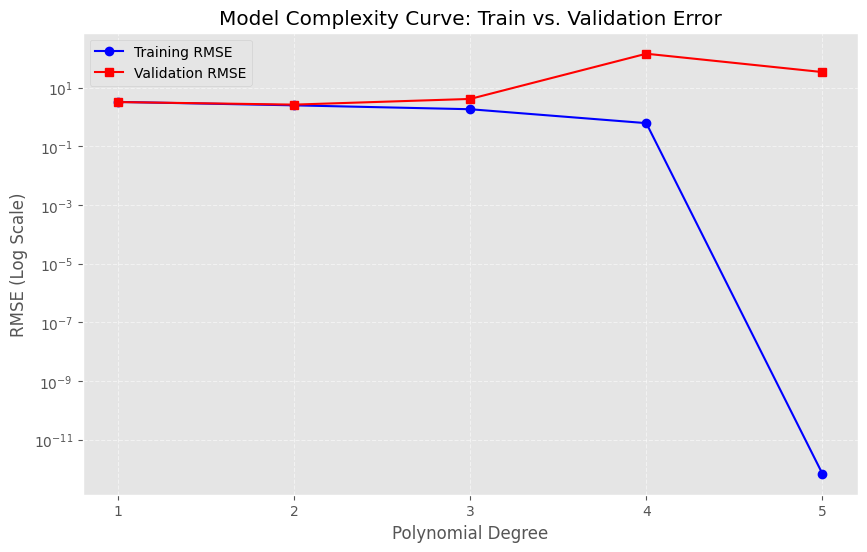

Running Optuna to find the optimal polynomial complexity...
Optuna Selected -> Degree: 2, Interaction Only: False

Final Polynomial Regression Metrics (Validation Set):
R^2:   0.8598
RMSE:  2.6752
MAE:   1.9719


In [40]:
import pandas as pd
import numpy as np
import zipfile
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- שלב 1: טעינת הנתונים וניקוי ---
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

try:
    with zipfile.ZipFile('auto+mpg.zip', 'r') as z:
        with z.open('auto-mpg.data') as f:
            df = pd.read_csv(f, sep=r'\s+', names=column_names, na_values='?')
except FileNotFoundError:
    print("קובץ ה-ZIP לא נמצא. וודאי שהוא הועלה למחברת.")

df = df.dropna()
X = df.drop(['mpg', 'car_name'], axis=1)
y = df['mpg']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- שלב 2: יצירת גרף מורכבות המודל (Model Complexity Curve) ---
degrees = [1, 2, 3, 4, 5]
train_rmses = []
val_rmses = []

for d in degrees:
    # שימוש ב-Pipeline שמבצע נרמול -> פולינום -> רגרסיה
    model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=d, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)

    # חישוב שגיאות
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))

    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)

# ציור הגרף הנדרש למטלה
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmses, marker='o', color='blue', label='Training RMSE')
plt.plot(degrees, val_rmses, marker='s', color='red', label='Validation RMSE')

# אנחנו משתמשים בציר Y לוגריתמי כי השגיאה בדרגות 4 ו-5 פשוט "מתפוצצת" בגלל Overfitting
plt.yscale('log')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Log Scale)')
plt.title('Model Complexity Curve: Train vs. Validation Error')
plt.xticks(degrees)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# --- שלב 3: אופטימיזציה עם Optuna לבחירת הפולינום הטוב ביותר ---
def objective(trial):
    # Optuna בודקת דרגות 1 עד 3 (יותר מזה זה Overfitting מובטח)
    degree = trial.suggest_int('degree', 1, 3)
    interaction_only = trial.suggest_categorical('interaction_only', [True, False])

    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, interaction_only=interaction_only, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    # המטרה: למזער את ה-RMSE על סט התיקוף
    return np.sqrt(mean_squared_error(y_val, val_pred))

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Running Optuna to find the optimal polynomial complexity...")
study = optuna.create_study(direction='minimize')
# 10 ניסויים מספיקים כי מרחב החיפוש כאן קטן
study.optimize(objective, n_trials=10)

best_deg = study.best_params['degree']
best_inter = study.best_params['interaction_only']
print(f"Optuna Selected -> Degree: {best_deg}, Interaction Only: {best_inter}")

# --- שלב 4: אימון המודל הסופי לפי תוצאות Optuna ---
final_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=best_deg, interaction_only=best_inter, include_bias=False),
    LinearRegression()
)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_final))
mae = mean_absolute_error(y_val, y_pred_final)
r2 = r2_score(y_val, y_pred_final)

print("\n" + "="*40)
print(f"Final Polynomial Regression Metrics (Validation Set):")
print(f"R^2:   {r2:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")
print("="*40)

# KNN

Best k (full search):  2
Best weights:          'distance'
Best p (distance):     1
Best Validation RMSE:  2.3091
Best k (uniform, p=2): 2  (RMSE=2.3936)


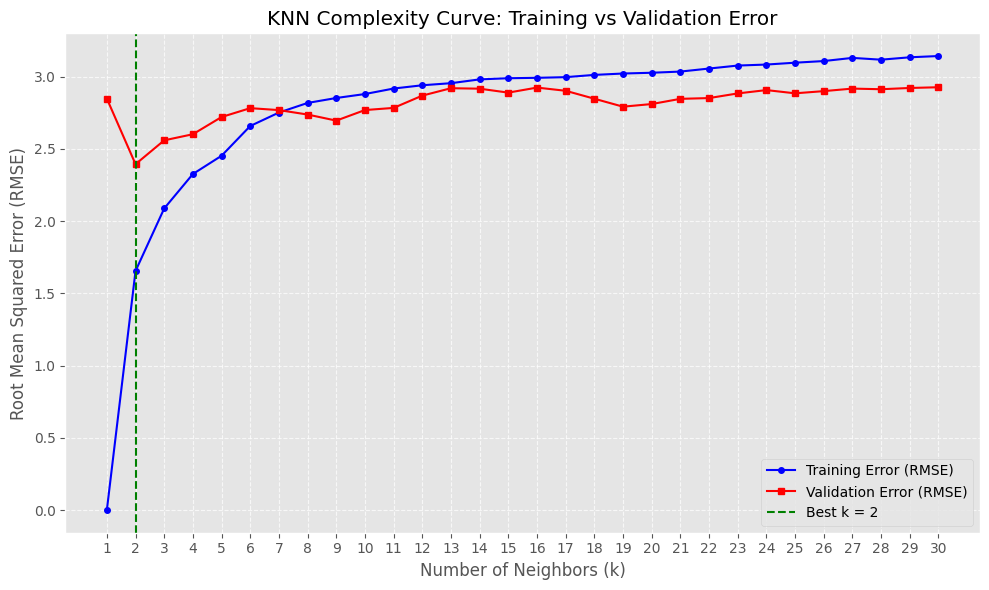

Saved: knn_complexity_curve.png


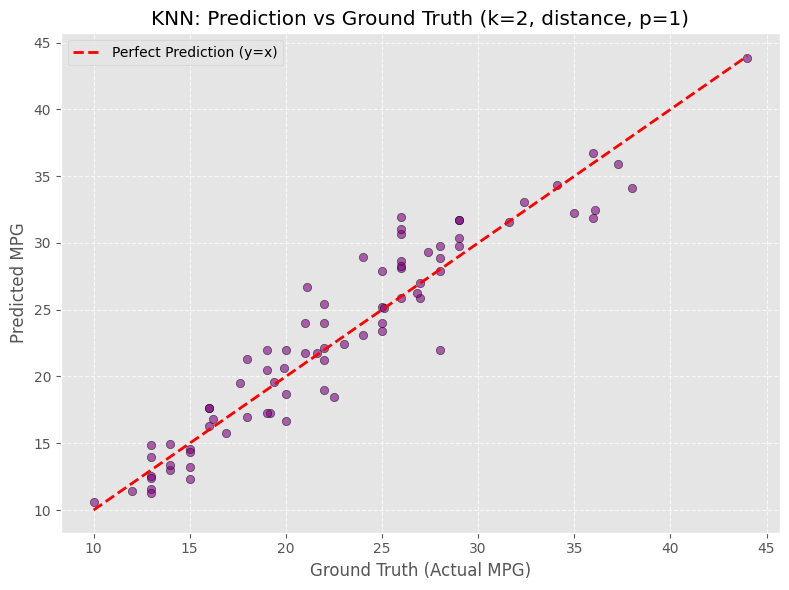

Saved: knn_prediction_vs_truth.png

--- Final KNN Metrics on Validation Set ---
k:       2
weights: 'distance'
p:       1
R²:      0.8955
RMSE:    2.3091
MAE:     1.7602


In [50]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- שלב 1: טעינת הנתונים והכנתם ---
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

with zipfile.ZipFile('auto+mpg.zip', 'r') as z:
    with z.open('auto-mpg.data') as f:
        df = pd.read_csv(f, sep=r'\s+', names=column_names, na_values='?')

df = df.dropna()

# Feature Engineering: הוספת log-transform לפיצ'רים א-סימטריים + פיצ'רים פיזיקליים
X = df.drop(['mpg', 'car_name'], axis=1).copy()
for col in ['displacement', 'horsepower', 'weight']:
    X[f'log_{col}'] = np.log(X[col])
X['displacement_per_cyl'] = X['displacement'] / X['cylinders']
X['power_to_weight'] = X['horsepower'] / X['weight']

y = df['mpg']

# Log-transform על משתנה המטרה - מתקן skewness ומשפר חיזוי KNN
y_log = np.log(y)

X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

# שמירת y_val בסקאלה המקורית להערכה
y_val_orig = np.exp(y_val_log)
y_train_orig = np.exp(y_train_log)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# --- שלב 2: חיפוש k אופטימלי ---
# Complexity curve עם uniform weights (להדגמת bias-variance tradeoff)
k_values = range(1, 31)
train_rmse_uniform = []
val_rmse_uniform = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', p=2)
    knn.fit(X_train_scaled, y_train_log)

    # המרה חזרה לסקאלה מקורית לחישוב RMSE
    tr_pred = np.exp(knn.predict(X_train_scaled))
    vl_pred = np.exp(knn.predict(X_val_scaled))

    train_rmse_uniform.append(np.sqrt(mean_squared_error(y_train_orig, tr_pred)))
    val_rmse_uniform.append(np.sqrt(mean_squared_error(y_val_orig, vl_pred)))

# חיפוש מקיף - כל הקומבינציות של weights ו-p
best_val_rmse = float('inf')
best_params = {}

for weights in ['uniform', 'distance']:
    for p in [1, 2]:
        for k in k_values:
            knn = KNeighborsRegressor(n_neighbors=k, weights=weights, p=p)
            knn.fit(X_train_scaled, y_train_log)
            vl_pred = np.exp(knn.predict(X_val_scaled))
            vr = np.sqrt(mean_squared_error(y_val_orig, vl_pred))
            if vr < best_val_rmse:
                best_val_rmse = vr
                best_params = {'k': k, 'weights': weights, 'p': p}

best_k_uniform = list(k_values)[np.argmin(val_rmse_uniform)]

print("="*50)
print(f"Best k (full search):  {best_params['k']}")
print(f"Best weights:          '{best_params['weights']}'")
print(f"Best p (distance):     {best_params['p']}")
print(f"Best Validation RMSE:  {best_val_rmse:.4f}")
print(f"Best k (uniform, p=2): {best_k_uniform}  (RMSE={min(val_rmse_uniform):.4f})")
print("="*50)

# --- שלב 3: Complexity Curve (uniform weights) ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_rmse_uniform, label='Training Error (RMSE)', marker='o', color='blue', markersize=4)
plt.plot(k_values, val_rmse_uniform, label='Validation Error (RMSE)', marker='s', color='red', markersize=4)
plt.axvline(x=best_k_uniform, color='green', linestyle='--',
            label=f'Best k = {best_k_uniform}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('KNN Complexity Curve: Training vs Validation Error')
plt.xticks(list(k_values))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('knn_complexity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: knn_complexity_curve.png")

# --- שלב 4: מודל סופי ---
final_knn = KNeighborsRegressor(
    n_neighbors=best_params['k'],
    weights=best_params['weights'],
    p=best_params['p']
)
final_knn.fit(X_train_scaled, y_train_log)
y_val_pred = np.exp(final_knn.predict(X_val_scaled))

# גרף תחזית מול מציאות
plt.figure(figsize=(8, 6))
plt.scatter(y_val_orig, y_val_pred, alpha=0.6, color='purple', edgecolors='k', linewidth=0.5)
min_v = min(y_val_orig.min(), y_val_pred.min())
max_v = max(y_val_orig.max(), y_val_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.title(f"KNN: Prediction vs Ground Truth (k={best_params['k']}, {best_params['weights']}, p={best_params['p']})")
plt.xlabel('Ground Truth (Actual MPG)')
plt.ylabel('Predicted MPG')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('knn_prediction_vs_truth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: knn_prediction_vs_truth.png")

# --- מדדים סופיים ---
final_rmse = np.sqrt(mean_squared_error(y_val_orig, y_val_pred))
final_mae = mean_absolute_error(y_val_orig, y_val_pred)
final_r2 = r2_score(y_val_orig, y_val_pred)

print("\n--- Final KNN Metrics on Validation Set ---")
print(f"k:       {best_params['k']}")
print(f"weights: '{best_params['weights']}'")
print(f"p:       {best_params['p']}")
print(f"R²:      {final_r2:.4f}")
print(f"RMSE:    {final_rmse:.4f}")
print(f"MAE:     {final_mae:.4f}")

# השוואת BGD עם MBGD

Optimizing Batch GD with Optuna (50 trials)...
  Best Val MSE: 11.0979 | Params: {'lr0': 0.0845670234963732, 'alpha': 0.0036794613289194765, 'lr_decay': 0.006714960746569094}
Optimizing Mini-batch GD (bs=32) with Optuna (50 trials)...
  Best Val MSE: 9.8442 | Params: {'lr0': 0.06505843442484634, 'alpha': 9.804363852635124e-06, 'lr_decay': 0.004114602607736304}
Optimizing SGD (bs=1) with Optuna (50 trials)...
  Best Val MSE: 9.3836 | Params: {'lr0': 0.06520480807062376, 'alpha': 4.5163979077639297e-05, 'lr_decay': 0.009793190976491398}


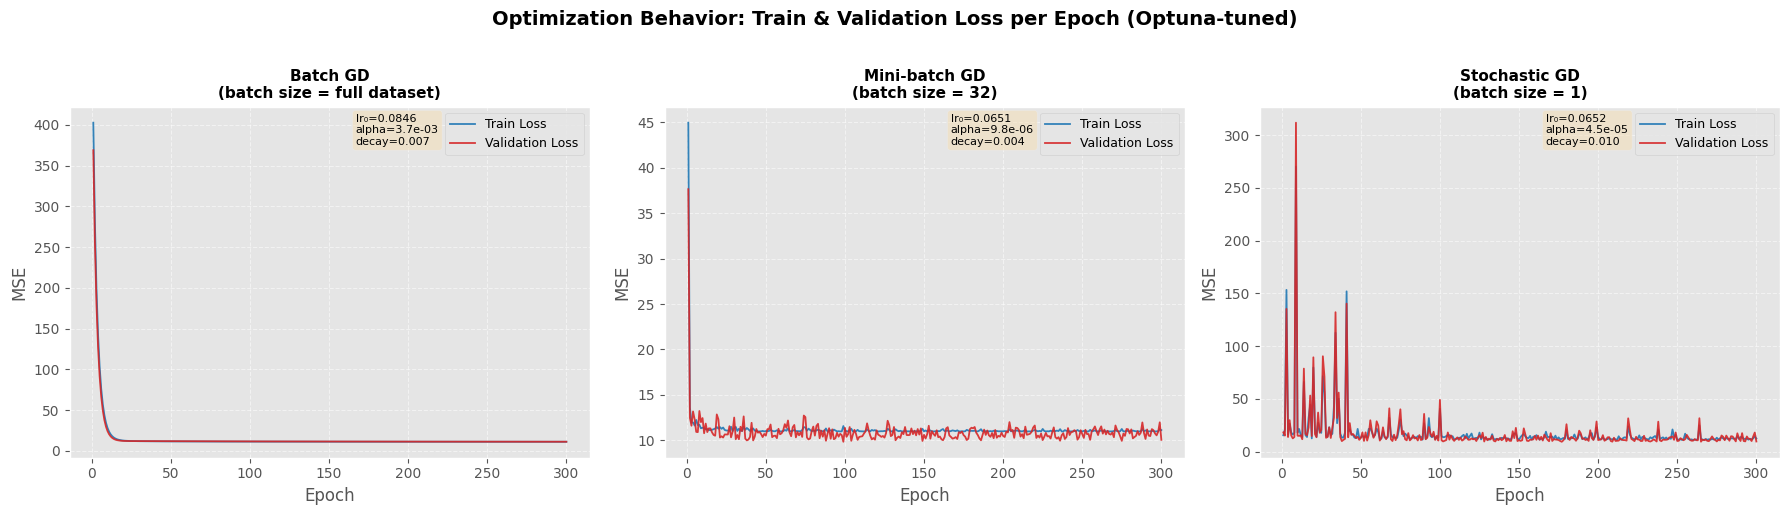

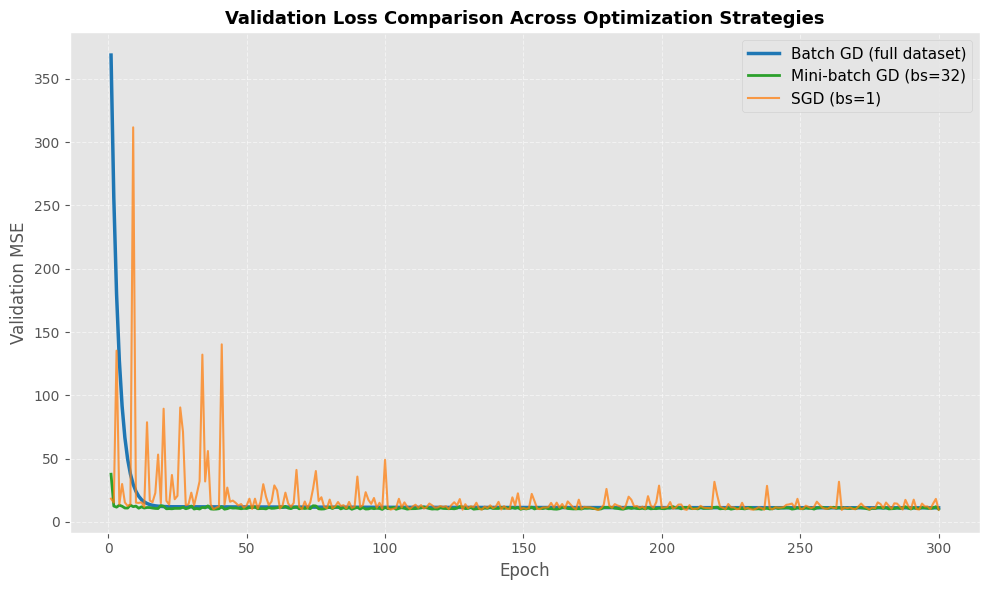

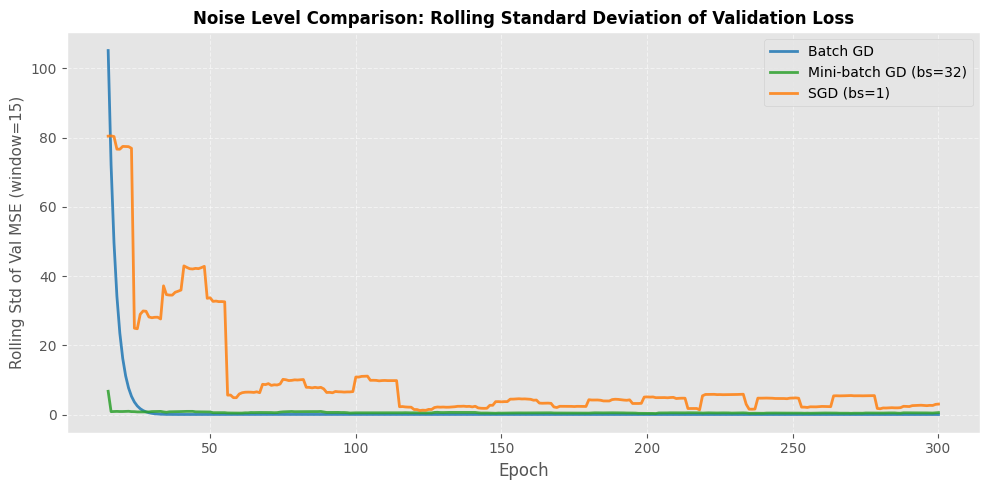


FINAL METRICS (Validation Set)
Strategy                        Final MSE   Best MSE       RMSE
-----------------------------------------------------------------
Batch GD                          11.0979    11.0979     3.3313
Mini-batch GD (bs=32)             10.0551     9.8442     3.1375
SGD (bs=1)                         9.6853     9.3836     3.0633


In [53]:
import pandas as pd
import numpy as np
import zipfile
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- שלב 1: טעינת נתונים ---
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

with zipfile.ZipFile('auto+mpg.zip', 'r') as z:
    with z.open('auto-mpg.data') as f:
        df = pd.read_csv(f, sep=r'\s+', names=column_names, na_values='?')

df = df.dropna()
X = df.drop(['mpg', 'car_name'], axis=1)
y = df['mpg']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

n_samples = X_train_scaled.shape[0]

# =============================================
# Gradient Descent ידני - שליטה מלאה על batch size, lr, regularization
# =============================================
def train_manual_gd(X_tr, y_tr, X_v, y_v, batch_size, epochs=300,
                     lr0=0.01, alpha=0.0001, lr_decay=0.005):
    """
    מימוש Gradient Descent ידני עם:
    - batch_size = n_samples  → Batch GD
    - batch_size = 32/64      → Mini-batch GD
    - batch_size = 1           → Stochastic GD (SGD)

    כולל learning rate decay: lr(t) = lr0 / (1 + decay * t)
    """
    np.random.seed(42)
    n, d = X_tr.shape
    y_arr = np.array(y_tr)
    y_v_arr = np.array(y_v)

    w = np.zeros(d)
    b = 0.0

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        lr = lr0 / (1 + lr_decay * epoch)

        idx = np.random.permutation(n)
        Xs, ys = X_tr[idx], y_arr[idx]

        for i in range(0, n, batch_size):
            Xb = Xs[i:i+batch_size]
            yb = ys[i:i+batch_size]
            m = len(yb)

            pred = Xb @ w + b
            error = pred - yb

            grad_w = (2/m) * (Xb.T @ error) + 2 * alpha * w
            grad_b = (2/m) * error.sum()

            w -= lr * grad_w
            b -= lr * grad_b

        tr_pred = X_tr @ w + b
        vl_pred = X_v @ w + b
        train_losses.append(np.mean((y_arr - tr_pred)**2))
        val_losses.append(np.mean((y_v_arr - vl_pred)**2))

    return train_losses, val_losses

# =============================================
# שלב 2: אופטימיזציה עם Optuna לכל אסטרטגיה
# =============================================
N_EPOCHS = 300

def objective(trial, batch_size):
    lr0 = trial.suggest_float('lr0', 1e-4, 0.1, log=True)
    alpha = trial.suggest_float('alpha', 1e-6, 0.1, log=True)
    lr_decay = trial.suggest_float('lr_decay', 0.001, 0.05)

    _, val_losses = train_manual_gd(
        X_train_scaled, y_train, X_val_scaled, y_val,
        batch_size=batch_size, epochs=N_EPOCHS,
        lr0=lr0, alpha=alpha, lr_decay=lr_decay
    )
    return min(val_losses)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Batch GD ---
print("Optimizing Batch GD with Optuna (50 trials)...")
study_batch = optuna.create_study(direction='minimize')
study_batch.optimize(lambda t: objective(t, n_samples), n_trials=50)
print(f"  Best Val MSE: {study_batch.best_value:.4f} | Params: {study_batch.best_params}")

# --- Mini-batch GD ---
print("Optimizing Mini-batch GD (bs=32) with Optuna (50 trials)...")
study_mini = optuna.create_study(direction='minimize')
study_mini.optimize(lambda t: objective(t, 32), n_trials=50)
print(f"  Best Val MSE: {study_mini.best_value:.4f} | Params: {study_mini.best_params}")

# --- SGD ---
print("Optimizing SGD (bs=1) with Optuna (50 trials)...")
study_sgd = optuna.create_study(direction='minimize')
study_sgd.optimize(lambda t: objective(t, 1), n_trials=50)
print(f"  Best Val MSE: {study_sgd.best_value:.4f} | Params: {study_sgd.best_params}")

# =============================================
# שלב 3: אימון סופי עם הפרמטרים הטובים ביותר
# =============================================
bp = study_batch.best_params
batch_tr, batch_vl = train_manual_gd(
    X_train_scaled, y_train, X_val_scaled, y_val,
    batch_size=n_samples, epochs=N_EPOCHS, **bp
)

mp = study_mini.best_params
mini_tr, mini_vl = train_manual_gd(
    X_train_scaled, y_train, X_val_scaled, y_val,
    batch_size=32, epochs=N_EPOCHS, **mp
)

sp = study_sgd.best_params
sgd_tr, sgd_vl = train_manual_gd(
    X_train_scaled, y_train, X_val_scaled, y_val,
    batch_size=1, epochs=N_EPOCHS, **sp
)

# =============================================
# שלב 4: גרפים
# =============================================
epochs_range = range(1, N_EPOCHS + 1)

# --- גרף 1: Loss Curves - 3 panels ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data = [
    ('Batch GD\n(batch size = full dataset)', batch_tr, batch_vl, bp),
    ('Mini-batch GD\n(batch size = 32)', mini_tr, mini_vl, mp),
    ('Stochastic GD\n(batch size = 1)', sgd_tr, sgd_vl, sp),
]

for ax, (title, tr, vl, params) in zip(axes, data):
    ax.plot(epochs_range, tr, label='Train Loss', linewidth=1.3, color='#1f77b4', alpha=0.9)
    ax.plot(epochs_range, vl, label='Validation Loss', linewidth=1.3, color='#d62728', alpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    info = f"lr₀={params['lr0']:.4f}\nalpha={params['alpha']:.1e}\ndecay={params['lr_decay']:.3f}"
    ax.text(0.55, 0.98, info, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Optimization Behavior: Train & Validation Loss per Epoch (Optuna-tuned)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('optimization_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- גרף 2: Validation Loss comparison ---
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, batch_vl, label='Batch GD (full dataset)', linewidth=2.5, color='#1f77b4')
plt.plot(epochs_range, mini_vl, label='Mini-batch GD (bs=32)', linewidth=2, color='#2ca02c')
plt.plot(epochs_range, sgd_vl, label='SGD (bs=1)', linewidth=1.5, color='#ff7f0e', alpha=0.75)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation MSE', fontsize=12)
plt.title('Validation Loss Comparison Across Optimization Strategies', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('optimization_val_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- גרף 3: Noise Analysis ---
window = 15
fig, ax = plt.subplots(figsize=(10, 5))
for label, vl, color in [('Batch GD', batch_vl, '#1f77b4'),
                           ('Mini-batch GD (bs=32)', mini_vl, '#2ca02c'),
                           ('SGD (bs=1)', sgd_vl, '#ff7f0e')]:
    rolling_std = pd.Series(vl).rolling(window).std()
    ax.plot(epochs_range, rolling_std, label=label, linewidth=2, color=color, alpha=0.85)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel(f'Rolling Std of Val MSE (window={window})', fontsize=11)
ax.set_title('Noise Level Comparison: Rolling Standard Deviation of Validation Loss',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('optimization_noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================
# שלב 5: סיכום מדדים
# =============================================
print("\n" + "="*65)
print("FINAL METRICS (Validation Set)")
print("="*65)
print(f"{'Strategy':<30} {'Final MSE':>10} {'Best MSE':>10} {'RMSE':>10}")
print("-"*65)
for name, vl in [('Batch GD', batch_vl), ('Mini-batch GD (bs=32)', mini_vl), ('SGD (bs=1)', sgd_vl)]:
    print(f"{name:<30} {vl[-1]:>10.4f} {min(vl):>10.4f} {np.sqrt(min(vl)):>10.4f}")
print("="*65)

# השוואת מודלים

Split: Train=250, Val=63, Test=79
Optimizing Linear Regression with Optuna (100 trials)...
  Best Val MSE: 7.8222 | Params: {'reg_type': 'ridge', 'alpha': 4.954706398730231}

Optimizing Polynomial Regression with Optuna (150 trials)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.646e+02, tolerance: 1.684e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.209e+02, tolerance: 1.684e+00
  model = cd_fast.enet_coordinate_descent(


  Best Val MSE: 5.8724 | Params: {'degree': 2, 'reg_type': 'elasticnet', 'alpha': 0.18376981260334407, 'l1_ratio': 0.7102380930738124}

KNN (from section 2.5): KNN (k=2, distance, p=1)

MODEL COMPARISON — VALIDATION SET (Optuna-optimized)
Model                                              MSE     RMSE      MAE       R²
--------------------------------------------------------------------------------
Linear (ridge)                                  7.8222   2.7968   2.1193   0.8303
Polynomial (deg=2, elasticnet)                  5.8724   2.4233   1.7127   0.8726
KNN (k=2, distance, p=1)                        9.5458   3.0896   2.0212   0.7929


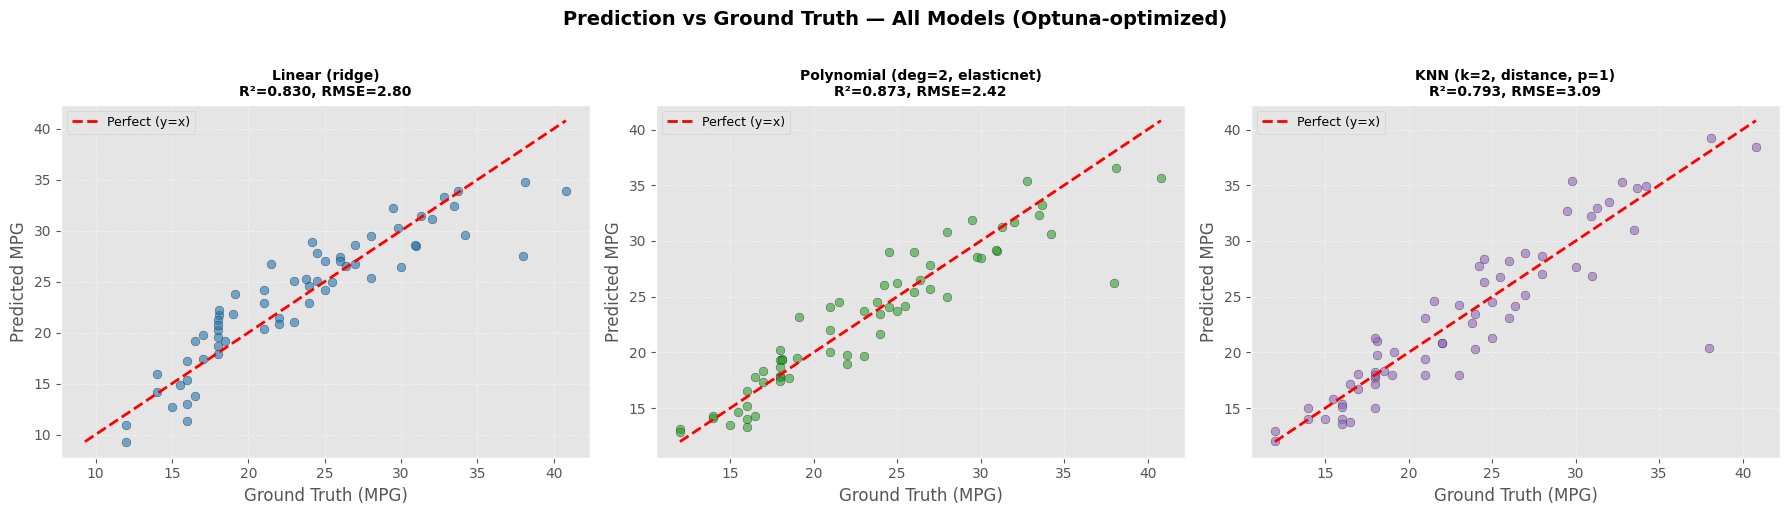

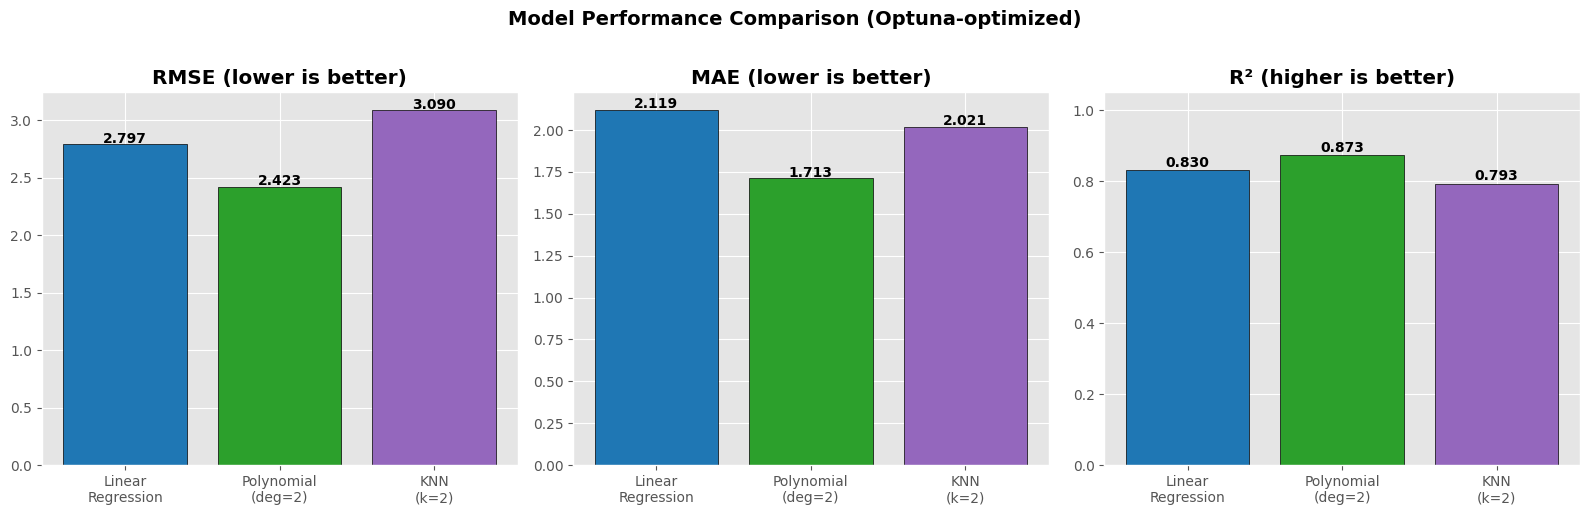

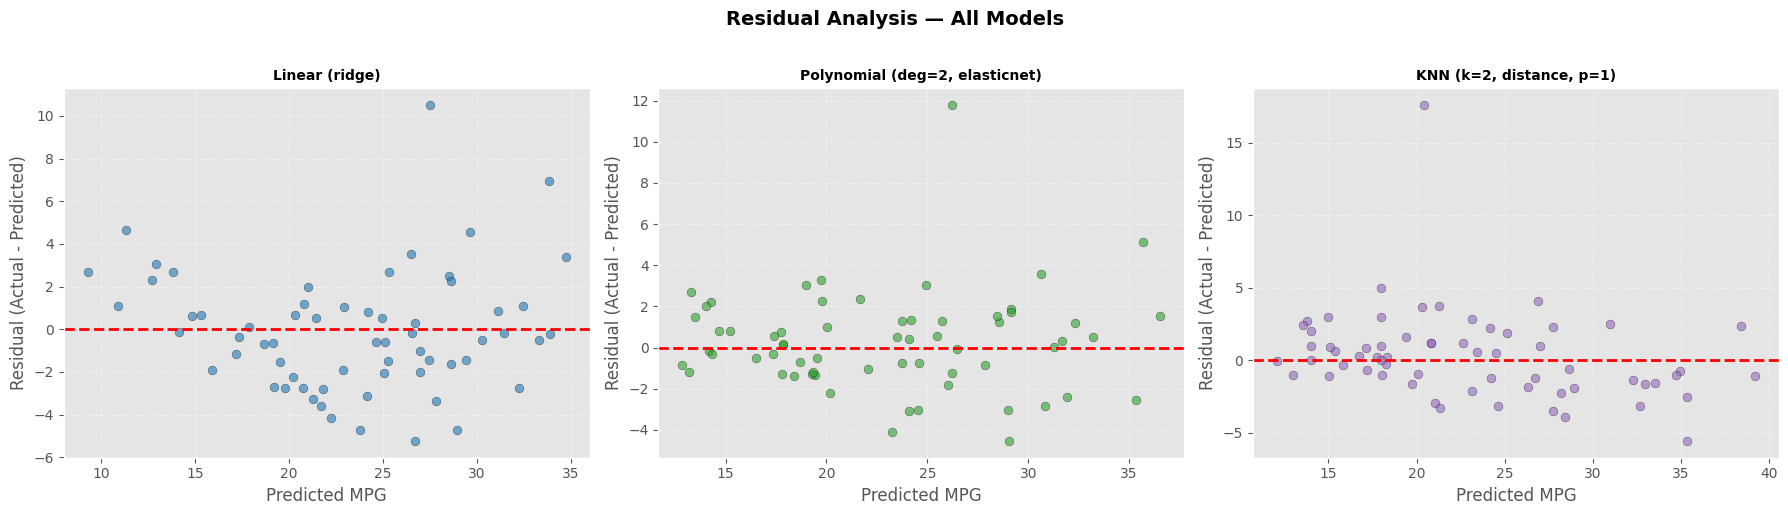


*** Winner (by Val RMSE): Polynomial (deg=2, elasticnet) ***

  FINAL PERFORMANCE ON TEST SET
  (Model retrained on Train+Val, evaluated on Test)
  Model:  Polynomial (deg=2, elasticnet)
  MSE:    6.5640
  RMSE:   2.5620
  MAE:    1.8269
  R²:     0.8714


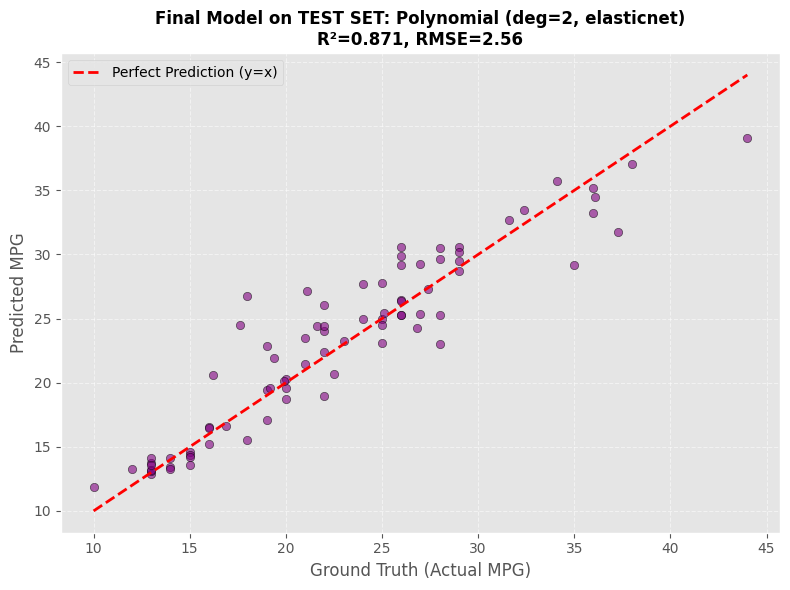

In [55]:
import pandas as pd
import numpy as np
import zipfile
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =============================================
# שלב 1: טעינת נתונים + חלוקה
# =============================================
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

with zipfile.ZipFile('auto+mpg.zip', 'r') as z:
    with z.open('auto-mpg.data') as f:
        df = pd.read_csv(f, sep=r'\s+', names=column_names, na_values='?')

df = df.dropna()
X = df.drop(['mpg', 'car_name'], axis=1)
y = df['mpg']

# Train+Val 80% / Test 20%
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train 80% / Val 20% (מתוך ה-80%)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

print(f"Split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================
# שלב 2: אופטימיזציה עם Optuna לכל מודל
# =============================================

# --- 1. Linear Regression (Optuna: בחירת רגולריזציה) ---
def objective_linear(trial):
    reg_type = trial.suggest_categorical('reg_type', ['none', 'ridge', 'lasso', 'elasticnet'])

    if reg_type == 'none':
        model = LinearRegression()
    elif reg_type == 'ridge':
        alpha = trial.suggest_float('alpha', 1e-4, 100, log=True)
        model = Ridge(alpha=alpha)
    elif reg_type == 'lasso':
        alpha = trial.suggest_float('alpha', 1e-4, 100, log=True)
        model = Lasso(alpha=alpha, max_iter=10000)
    else:
        alpha = trial.suggest_float('alpha', 1e-4, 100, log=True)
        l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)

    model.fit(X_train_scaled, y_train)
    return mean_squared_error(y_val, model.predict(X_val_scaled))

print("Optimizing Linear Regression with Optuna (100 trials)...")
study_lr = optuna.create_study(direction='minimize')
study_lr.optimize(objective_linear, n_trials=100)
print(f"  Best Val MSE: {study_lr.best_value:.4f} | Params: {study_lr.best_params}")

# אימון המודל הטוב ביותר
bp_lr = study_lr.best_params
if bp_lr['reg_type'] == 'none':
    best_lr_model = LinearRegression()
elif bp_lr['reg_type'] == 'ridge':
    best_lr_model = Ridge(alpha=bp_lr['alpha'])
elif bp_lr['reg_type'] == 'lasso':
    best_lr_model = Lasso(alpha=bp_lr['alpha'], max_iter=10000)
else:
    best_lr_model = ElasticNet(alpha=bp_lr['alpha'], l1_ratio=bp_lr['l1_ratio'], max_iter=10000)

best_lr_model.fit(X_train_scaled, y_train)
y_val_pred_lr = best_lr_model.predict(X_val_scaled)
lr_label = f"Linear ({bp_lr['reg_type']})"

# --- 2. Polynomial Regression (Optuna: דרגה + רגולריזציה) ---
def objective_poly(trial):
    degree = trial.suggest_int('degree', 2, 4)
    reg_type = trial.suggest_categorical('reg_type', ['none', 'ridge', 'lasso', 'elasticnet'])

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr_poly = poly.fit_transform(X_train_scaled)
    X_vl_poly = poly.transform(X_val_scaled)

    if reg_type == 'none':
        model = LinearRegression()
    elif reg_type == 'ridge':
        alpha = trial.suggest_float('alpha', 1e-4, 1000, log=True)
        model = Ridge(alpha=alpha)
    elif reg_type == 'lasso':
        alpha = trial.suggest_float('alpha', 1e-4, 1000, log=True)
        model = Lasso(alpha=alpha, max_iter=10000)
    else:
        alpha = trial.suggest_float('alpha', 1e-4, 1000, log=True)
        l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)

    model.fit(X_tr_poly, y_train)
    return mean_squared_error(y_val, model.predict(X_vl_poly))

print("\nOptimizing Polynomial Regression with Optuna (150 trials)...")
study_poly = optuna.create_study(direction='minimize')
study_poly.optimize(objective_poly, n_trials=150)
print(f"  Best Val MSE: {study_poly.best_value:.4f} | Params: {study_poly.best_params}")

# אימון הפולינום הטוב ביותר
bp_poly = study_poly.best_params
best_poly_degree = bp_poly['degree']
best_poly_features = PolynomialFeatures(degree=best_poly_degree, include_bias=False)
X_tr_poly = best_poly_features.fit_transform(X_train_scaled)
X_vl_poly = best_poly_features.transform(X_val_scaled)

if bp_poly['reg_type'] == 'none':
    best_poly_model = LinearRegression()
elif bp_poly['reg_type'] == 'ridge':
    best_poly_model = Ridge(alpha=bp_poly['alpha'])
elif bp_poly['reg_type'] == 'lasso':
    best_poly_model = Lasso(alpha=bp_poly['alpha'], max_iter=10000)
else:
    best_poly_model = ElasticNet(alpha=bp_poly['alpha'], l1_ratio=bp_poly.get('l1_ratio', 0.5), max_iter=10000)

best_poly_model.fit(X_tr_poly, y_train)
y_val_pred_poly = best_poly_model.predict(X_vl_poly)
poly_label = f"Polynomial (deg={best_poly_degree}, {bp_poly['reg_type']})"

# --- 3. KNN Regression (פרמטרים שנבחרו בסעיף 2.5 — לא מחפשים מחדש) ---
best_k = 2
best_knn_weights = 'distance'
best_knn_p = 1

best_knn_model = KNeighborsRegressor(n_neighbors=best_k, weights=best_knn_weights, p=best_knn_p)
best_knn_model.fit(X_train_scaled, y_train)
y_val_pred_knn = best_knn_model.predict(X_val_scaled)
knn_label = f"KNN (k={best_k}, {best_knn_weights}, p={best_knn_p})"
print(f"\nKNN (from section 2.5): {knn_label}")

# =============================================
# שלב 3: מדדים על Validation
# =============================================
def compute_metrics(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred)
    }

m_lr   = compute_metrics(y_val, y_val_pred_lr)
m_poly = compute_metrics(y_val, y_val_pred_poly)
m_knn  = compute_metrics(y_val, y_val_pred_knn)

print("\n" + "="*80)
print("MODEL COMPARISON — VALIDATION SET (Optuna-optimized)")
print("="*80)
print(f"{'Model':<45} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-"*80)
for name, m in [(lr_label, m_lr), (poly_label, m_poly), (knn_label, m_knn)]:
    print(f"{name:<45} {m['MSE']:>8.4f} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} {m['R²']:>8.4f}")
print("="*80)

# =============================================
# שלב 4: גרפים
# =============================================
models_vis = [
    (lr_label, y_val_pred_lr, m_lr, '#1f77b4'),
    (poly_label, y_val_pred_poly, m_poly, '#2ca02c'),
    (knn_label, y_val_pred_knn, m_knn, '#9467bd'),
]

# --- גרף 1: Prediction vs Ground Truth ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, y_pred, m, color) in zip(axes, models_vis):
    ax.scatter(y_val, y_pred, alpha=0.6, color=color, edgecolors='k', linewidth=0.3, s=40)
    lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect (y=x)')
    ax.set_title(f"{title}\nR²={m['R²']:.3f}, RMSE={m['RMSE']:.2f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Ground Truth (MPG)')
    ax.set_ylabel('Predicted MPG')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Prediction vs Ground Truth — All Models (Optuna-optimized)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_pred_vs_truth.png', dpi=150, bbox_inches='tight')
plt.show()

# --- גרף 2: Bar Chart ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
short_labels = ['Linear\nRegression', f'Polynomial\n(deg={best_poly_degree})', f'KNN\n(k={best_k})']
colors = ['#1f77b4', '#2ca02c', '#9467bd']

for ax, key, title_str in zip(axes, ['RMSE', 'MAE', 'R²'],
    ['RMSE (lower is better)', 'MAE (lower is better)', 'R² (higher is better)']):
    vals = [m_lr[key], m_poly[key], m_knn[key]]
    bars = ax.bar(short_labels, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title_str, fontweight='bold')
    if key == 'R²':
        ax.set_ylim(0, 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Model Performance Comparison (Optuna-optimized)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# --- גרף 3: Residuals ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, y_pred, _, color) in zip(axes, models_vis):
    residuals = y_val - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, color=color, edgecolors='k', linewidth=0.3, s=40)
    ax.axhline(y=0, color='red', linestyle='--', lw=2)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted MPG')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Residual Analysis — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================
# שלב 5: מודל סופי → אימון על Train+Val, הערכה על Test
# =============================================
all_candidates = {
    lr_label: (m_lr, 'linear'),
    poly_label: (m_poly, 'poly'),
    knn_label: (m_knn, 'knn'),
}
winner_name = min(all_candidates, key=lambda k: all_candidates[k][0]['RMSE'])
winner_type = all_candidates[winner_name][1]

print(f"\n*** Winner (by Val RMSE): {winner_name} ***")

# אימון מחדש על כל trainval
scaler_final = StandardScaler()
X_trainval_scaled = scaler_final.fit_transform(X_trainval)
X_test_scaled = scaler_final.transform(X_test)

if winner_type == 'linear':
    final_model = best_lr_model.__class__(**best_lr_model.get_params())
    final_model.fit(X_trainval_scaled, y_trainval)
    y_test_pred = final_model.predict(X_test_scaled)
elif winner_type == 'poly':
    poly_final = PolynomialFeatures(degree=best_poly_degree, include_bias=False)
    X_tv_poly = poly_final.fit_transform(X_trainval_scaled)
    X_te_poly = poly_final.transform(X_test_scaled)
    final_model = best_poly_model.__class__(**best_poly_model.get_params())
    final_model.fit(X_tv_poly, y_trainval)
    y_test_pred = final_model.predict(X_te_poly)
else:
    final_model = KNeighborsRegressor(n_neighbors=best_k, weights=best_knn_weights, p=best_knn_p)
    final_model.fit(X_trainval_scaled, y_trainval)
    y_test_pred = final_model.predict(X_test_scaled)

test_m = compute_metrics(y_test, y_test_pred)

print(f"\n{'='*60}")
print(f"  FINAL PERFORMANCE ON TEST SET")
print(f"  (Model retrained on Train+Val, evaluated on Test)")
print(f"{'='*60}")
print(f"  Model:  {winner_name}")
print(f"  MSE:    {test_m['MSE']:.4f}")
print(f"  RMSE:   {test_m['RMSE']:.4f}")
print(f"  MAE:    {test_m['MAE']:.4f}")
print(f"  R²:     {test_m['R²']:.4f}")
print(f"{'='*60}")

# Test set plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='purple', edgecolors='k', linewidth=0.5)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.title(f'Final Model on TEST SET: {winner_name}\nR²={test_m["R²"]:.3f}, RMSE={test_m["RMSE"]:.2f}',
          fontsize=12, fontweight='bold')
plt.xlabel('Ground Truth (Actual MPG)')
plt.ylabel('Predicted MPG')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('final_model_test_performance.png', dpi=150, bbox_inches='tight')
plt.show()
